## Loading Datasets, creating KDEs, evaluating on fine-grain M and R grid

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
import seaborn as sns
import matplotlib as mpl
from scipy.ndimage import gaussian_filter

# Model definitions
MODELS = {
    "ST_PST19": dict(file="datafiles/ST_PST19", color="tab:pink",   label="Riley19: ST+PST"),
    "ST_PDT":   dict(file="datafiles/ST_PDT",   color="tab:blue",   label="Vinciguerra23: ST+PDT"),
    "ST_PST":   dict(file="datafiles/ST_PST",   color="tab:orange", label="Vinciguerra23: ST+PST"),
    "PDT_U":    dict(file="datafiles/PDT_U",    color="tab:green",  label="Vinciguerra23: PDT--U"),
    "ST_U":     dict(file="datafiles/ST_U",     color="tab:cyan",   label="Vinciguerra23: ST--U"),
    "2spot":    dict(file="datafiles/2spot",    color="tab:red",    label="Miller19: 2spot"),
    "3spot":    dict(file="datafiles/3spot",    color="tab:purple", label="Miller19: 3spot"),
    "PDT_U26": dict(file="datafiles/PDT_U26",  color="tab:olive",  label="Vinciguerra23: PDT--U26"),
}

# ------------------------------------------------------------
# Load data and compute summary statistics
# ------------------------------------------------------------

samples_MR = {}

M_med, M_lo, M_hi, S_Mi = {}, {}, {}, {}
R_med, R_lo, R_hi, S_Ri = {}, {}, {}, {}
KDEs_2D = {}
for key, meta in MODELS.items():

    data = np.loadtxt(meta["file"])
    M, R = data.T[0], data.T[1]

    samples_MR[key] = np.vstack([M, R])

    # Mass statistics
    M_med[key] = np.median(M)
    M_lo[key]  = np.min(M)
    M_hi[key]  = np.max(M)
    S_Mi[key]  = max(M_hi[key] - M_med[key],
                     M_med[key] - M_lo[key])

    # Radius statistics
    R_med[key] = np.median(R)
    R_lo[key]  = np.min(R)
    R_hi[key]  = np.max(R)
    S_Ri[key]  = max(R_hi[key] - R_med[key],
                     R_med[key] - R_lo[key])

    print(
        rf"{meta['label']}: "
        rf"M = {M_med[key]:.3f} (+{M_hi[key]:.3f}/-{M_lo[key]:.3f}), "
        rf"R = {R_med[key]:.3f} (+{R_hi[key]:.3f}/-{R_lo[key]:.3f})"
    )

    KDEs_2D[key] = gaussian_kde(samples_MR[key], bw_method="silverman")

# ------------------------------------------------------------
# Common 2D grid
# ------------------------------------------------------------

M_grid = np.linspace(1.0, 2.2, 100)
R_grid = np.linspace(9.0, 17.0, 100)

dM = M_grid[1] - M_grid[0]
dR = R_grid[1] - R_grid[0]

MM, RR = np.meshgrid(M_grid, R_grid, indexing="ij")
pos = np.vstack([MM.ravel(), RR.ravel()])

# ------------------------------------------------------------
# Evaluate KDEs on grid
# ------------------------------------------------------------

g_dict = {}
for key in MODELS:

    g = KDEs_2D[key](pos).reshape(MM.shape)

    g /= np.trapz(
            np.trapz(g, R_grid, axis=1),
            M_grid
        )

    g_dict[key] = g

g_stack = np.array([g_dict[key] for key in MODELS])
# shape: (Ndata, NM, NR)

Riley19: ST+PST: M = 1.289 (+1.879/-1.001), R = 12.574 (+16.000/-9.245)
Vinciguerra23: ST+PDT: M = 1.395 (+1.906/-1.020), R = 11.714 (+14.971/-9.044)
Vinciguerra23: ST+PST: M = 1.927 (+2.220/-1.061), R = 15.232 (+16.000/-9.426)
Vinciguerra23: PDT--U: M = 1.702 (+2.220/-1.009), R = 14.435 (+16.000/-10.566)
Vinciguerra23: ST--U: M = 1.883 (+2.244/-1.003), R = 15.117 (+16.000/-8.410)
Miller19: 2spot: M = 1.442 (+2.374/-1.000), R = 13.271 (+19.718/-9.285)
Miller19: 3spot: M = 1.440 (+2.247/-1.000), R = 13.012 (+19.702/-8.905)


## Combination (Fgood = KDE (shifted by delta), Fbad = Gaussian of width S|)

In [13]:
# SETTINGS

sigma_grid = np.logspace(-3, -0.3, 40)

# Jeffreys prior on sigma_shift
prior_sigma = 1.0 / sigma_grid
prior_sigma /= np.trapz(prior_sigma, sigma_grid)

# Mixture parameter grid (uniform prior)
p_grid = np.linspace(0, 1, 80)

P_MR_given_sigma = []
evidence_sigma = []

# Combination LOOP
for k, sigma in enumerate(sigma_grid):

    # Shifted likelihoods for this sigma
    shifted_likelihoods = {}

    for key in MODELS:

        # Original KDE on grid
        L_i = g_dict[key]

        # Convert physical sigma to pixel units
        sigma_pixels_M = sigma / dM
        sigma_pixels_R = sigma / dR

        # Apply 2D Gaussian smoothing
        L_i_shifted = gaussian_filter(
            L_i,
            sigma=[sigma_pixels_M, sigma_pixels_R]
        )

        # Renormalize after smoothing
        L_i_shifted /= np.trapz(
                            np.trapz(L_i_shifted, R_grid, axis=1),
                            M_grid
                        )

        shifted_likelihoods[key] = L_i_shifted

    # Build P(M,R | sigma) by marginalizing over p
    P_MR_sigma = np.zeros_like(MM)

    for p in p_grid:

        product_likelihood = np.ones_like(MM)

        for key in MODELS:

            f_good = shifted_likelihoods[key]

            # Broad 2D Gaussian bad model
            f_bad = (
                norm.pdf(MM,
                         loc=M_med[key],
                         scale=S_Mi[key]) *
                norm.pdf(RR,
                         loc=R_med[key],
                         scale=S_Ri[key])
            )

            mixture = p * f_good + (1 - p) * f_bad

            product_likelihood *= mixture

        P_MR_sigma += product_likelihood

    # Uniform prior on p → average over grid
    P_MR_sigma /= len(p_grid)

    # Evidence for this sigma
    Z_sigma = np.trapz(
                    np.trapz(P_MR_sigma, R_grid, axis=1),
                    M_grid
                )

    evidence_sigma.append(Z_sigma)

    # Store normalized P(M,R | sigma)
    P_MR_given_sigma.append(P_MR_sigma / Z_sigma)

P_MR_given_sigma = np.array(P_MR_given_sigma)
evidence_sigma = np.array(evidence_sigma)

# ---------------------------------------------------
# POSTERIOR OVER sigma_shift
# ---------------------------------------------------

posterior_sigma = evidence_sigma * prior_sigma
posterior_sigma /= np.trapz(posterior_sigma, sigma_grid)

# ---------------------------------------------------
# FINAL POSTERIOR OVER (M,R)
# ---------------------------------------------------

posterior_2d = np.zeros_like(MM)

for k in range(len(sigma_grid)):
    posterior_2d += P_MR_given_sigma[k] * posterior_sigma[k]

posterior_2d /= np.trapz(
                        np.trapz(posterior_2d, R_grid, axis=1),
                        M_grid
                    )

# ---------------------------------------------------
# SUMMARY STATISTICS
# ---------------------------------------------------

# Marginals
P_R = np.trapz(posterior_2d, M_grid, axis=0)
P_R /= np.trapz(P_R, R_grid)

P_M = np.trapz(posterior_2d, R_grid, axis=1)
P_M /= np.trapz(P_M, M_grid)

# Quantiles
def compute_quantiles(grid, pdf):
    cdf = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf /= cdf[-1]
    return np.interp([0.16, 0.50, 0.84], cdf, grid)

R_q16, R_q50, R_q84 = compute_quantiles(R_grid, P_R)
M_q16, M_q50, M_q84 = compute_quantiles(M_grid, P_M)

print("\nFinal marginalized constraints:")
print(f"Radius median: {R_q50:.4f}")
print(f"Radius 68%: [{R_q16:.4f}, {R_q84:.4f}]")
print(f"Mass median: {M_q50:.4f}")
print(f"Mass 68%: [{M_q16:.4f}, {M_q84:.4f}]")

# sigma summary
d_sigma = sigma_grid[1] - sigma_grid[0]
cdf_sigma = np.cumsum(posterior_sigma) * d_sigma
sigma_quantiles = np.interp([0.16, 0.50, 0.84],
                            cdf_sigma,
                            sigma_grid)

print("\nInferred sigma_shift:")
print(f"Median: {sigma_quantiles[1]:.5f}")
print(f"68% interval: "
      f"[{sigma_quantiles[0]:.5f}, {sigma_quantiles[2]:.5f}]")


Final marginalized constraints:
Radius median: 12.9617
Radius 68%: [12.2951, 13.7140]
Mass median: 1.5172
Mass 68%: [1.4328, 1.6181]

Inferred sigma_shift:
Median: 0.50119
68% interval: [0.50119, 0.50119]


## Plotting

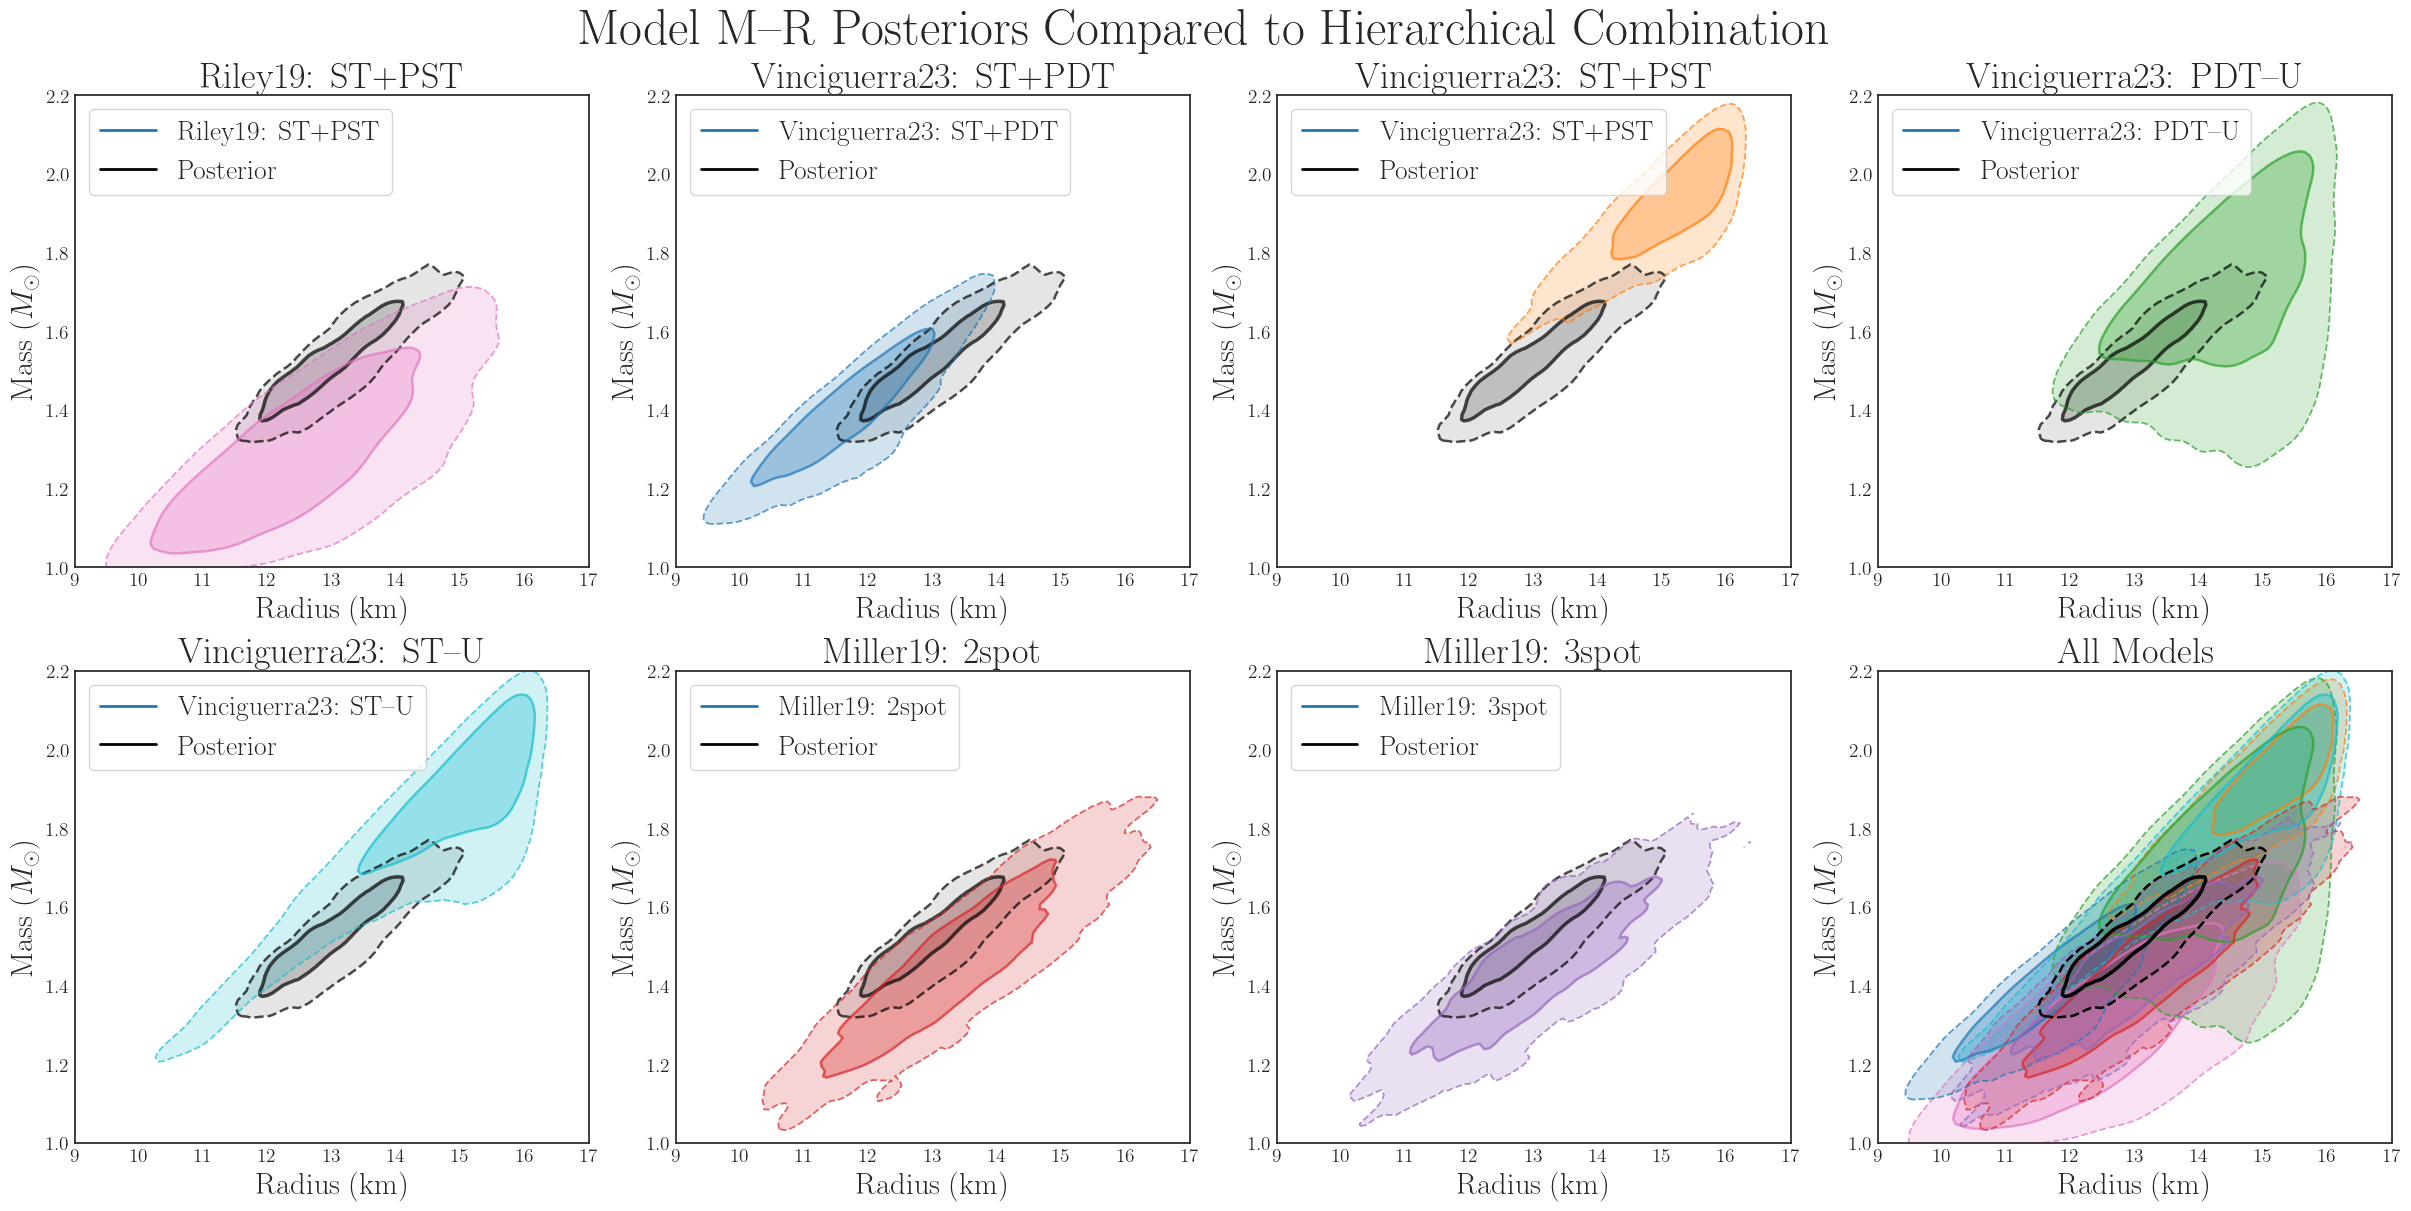

In [11]:
plt.style.use('seaborn-v0_8-white')
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# ------------------------------------------------------------
# HDR level computation
# ------------------------------------------------------------

posterior = posterior_2d

def compute_hdr_levels(pdf, probs=(0.68, 0.95)):

    flat = pdf.ravel()
    idx = np.argsort(flat)[::-1]
    sorted_pdf = flat[idx]

    cumsum = np.cumsum(sorted_pdf)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        levels.append(sorted_pdf[np.searchsorted(cumsum, p)])

    return levels


# Posterior levels
posterior_lvl68, posterior_lvl95 = compute_hdr_levels(posterior, (0.68, 0.95))

# Models to compare
compare_series = [
    (key, MODELS[key]["label"])
    for key in MODELS
]

# 2 × 4 layout
fig, axes = plt.subplots(2, 4, figsize=(24, 12), constrained_layout=True)

def rgba(color, alpha):
    return mpl.colors.to_rgba(color, alpha)

# ------------------------------------------------------------
# Panels 1–7: individual vs posterior
# ------------------------------------------------------------

for ax, (key, label) in zip(axes.flatten()[:7], compare_series):

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Posterior fill
    ax.contourf(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
        colors=[rgba("black", 0.10), rgba("black", 0.25)],
        antialiased=True
    )

    # Individual fill
    ax.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.20), rgba(MODELS[key]["color"], 0.45)],
        antialiased=True
    )

    # Posterior outline
    ax.contour(
        R_grid, M_grid, posterior,
        levels=[posterior_lvl95, posterior_lvl68],
        colors=rgba("black", 0.7),
        linewidths=[1.8, 2.5],
        linestyles=['--', '-']
    )

    # Individual outline
    ax.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

    ax.set_title(label, fontsize=26)
    ax.set_xlabel("Radius (km)", fontsize=22)
    ax.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
    ax.minorticks_on()
    ax.tick_params(labelsize=14)

    ax.legend(
        handles=[
            mpl.lines.Line2D([], [], color='tab:blue', linewidth=2, label=label),
            mpl.lines.Line2D([], [], color='black', linewidth=2, label='Posterior')
        ],
        fontsize=20,
        loc='upper left',
        frameon=True,
        fancybox=True,
        framealpha=0.8
    )

# ------------------------------------------------------------
# Panel 8: all models + posterior
# ------------------------------------------------------------

ax_all = axes.flatten()[7]

for key, label in compare_series:

    density = g_dict[key]
    lvl68, lvl95 = compute_hdr_levels(density, (0.68, 0.95))

    # Individual fill
    ax_all.contourf(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68, density.max()],
        colors=[rgba(MODELS[key]["color"], 0.20), rgba(MODELS[key]["color"], 0.45)],
        antialiased=True
    )
    
    # Individual outline
    ax_all.contour(
        R_grid, M_grid, density,
        levels=[lvl95, lvl68],
        colors=rgba(MODELS[key]["color"], 0.7),
        linewidths=[1.3, 1.8],
        linestyles=['--', '-'],
    )

# Posterior fill
ax_all.contourf(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68, posterior.max()],
    colors=[rgba("black", 0.10), rgba("black", 0.25)],
    antialiased=True
)

# Posterior outline
ax_all.contour(
    R_grid, M_grid, posterior,
    levels=[posterior_lvl95, posterior_lvl68],
    colors='black',
    linewidths=[1.8, 2.5],
    linestyles=['--', '-']
)

ax_all.set_title("All Models", fontsize=26)
ax_all.set_xlabel("Radius (km)", fontsize=22)
ax_all.set_ylabel("Mass ($M_\\odot$)", fontsize=22)
ax_all.minorticks_on()
ax_all.tick_params(labelsize=14)

fig.suptitle(
    "Model M--R Posteriors Compared to Hierarchical Combination",
    fontsize=36
)

plt.show()

In [14]:
P_vi = {}
epsilon = 1e-300

for key_i in MODELS:

    total_prob = 0.0

    for iM, sigma_M in enumerate(sigma_M_grid):
        for iR, sigma_R in enumerate(sigma_R_grid):

            d_sigma_M = sigma_M_grid[1] - sigma_M_grid[0]
            d_sigma_R = sigma_R_grid[1] - sigma_R_grid[0]

            weight_sigma = (
                posterior_sigma_MR[iM, iR]
                * d_sigma_M
                * d_sigma_R
            )

            g_i = g_dict[key_i]                     # (NM, NR)
            b_i = b_dict[key_i][iM, iR]             # (NM, NR)
            P_sigma = P_MR_given_sigma[iM, iR]      # (NM, NR)

            # --- rebuild L_p exactly as in combination ---
            b_stack = np.array([
                b_dict[key][iM, iR] for key in MODELS
            ])

            g_exp = g_stack[:, None, :, :]          # (Ndata, Np, NM, NR)
            b_exp = b_stack[:, None, :, :]
            p_exp = p_grid[None, :, None, None]

            mixture = p_exp * g_exp + (1 - p_exp) * b_exp
            L_p = np.prod(mixture, axis=0)          # (Np, NM, NR)

            # --- compute fraction for this model ---
            p_vals = p_grid[:, None, None]          # (Np,1,1)

            numerator_i = p_vals * g_i              # broadcast to (Np,NM,NR)
            denominator_i = (
                p_vals * g_i + (1 - p_vals) * b_i + epsilon
            )

            frac = numerator_i / denominator_i      # (Np,NM,NR)

            # --- weighted integral over p ---
            weighted = frac * L_p                   # (Np,NM,NR)

            numerator = np.trapz(weighted, p_grid, axis=0)     # (NM,NR)
            denominator = np.trapz(L_p, p_grid, axis=0)        # (NM,NR)

            P_vi_given_sigma = numerator / (denominator + epsilon)

            # --- integrate over M,R ---
            contribution = np.trapz(
                                np.trapz(
                                    P_vi_given_sigma * P_sigma,
                                    R_grid,
                                    axis=1
                                ),
                                M_grid
                            )

            total_prob += weight_sigma * contribution

    P_vi[key_i] = total_prob

    print(f"Posterior probability {key_i} is good: {P_vi[key_i]:.4f}")

NameError: name 'sigma_M_grid' is not defined